# NYC Taxi Demand: EDA and Modeling
This notebook covers:
- loading processed daily taxi + weather data
- exploratory analysis and business framing
- baseline and model-based demand forecasting
- policy-impact quick readout (congestion pricing)

## Executive Summary (Non-Technical)
This project builds a production-style analytics pipeline on NYC taxi trip data to predict fares and surface demand patterns for operational planning.

It combines robust data preparation, model benchmarking (baseline + boosted models), temporal validation, and SHAP explainability to produce reliable and interpretable outputs.

Key value: strong predictive performance, clear business insights on peak demand timing, and a deployment-ready Streamlit app for interactive prediction and decision support.

## Introduction and Background
New York City taxi demand and fare behavior are highly time-dependent and affected by trip characteristics, payment behavior, and policy changes such as congestion pricing.

This notebook builds an end-to-end analytics and modeling workflow to:
- prepare and clean taxi trip data
- explore demand and fare patterns
- train and compare predictive models
- validate results with temporal methods
- explain model behavior for stakeholder trust

## Notebook Outline
1. Data preparation (cleaning, feature engineering, and train/test setup)
2. Exploratory Data Analysis (EDA) on demand and fare dynamics
3. Modeling and evaluation (baseline, boosted models, temporal validation)
4. Explainability (SHAP global and local interpretation)
5. Summary and recommendations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)

## Data Preparation
This section loads the prepared data, checks quality, handles missing values/outliers, and creates model-ready features.

Preparation goals:
- preserve realistic trip behavior while removing obvious data issues
- engineer time-based predictors (hour, day-of-week, weekend, month)
- construct a reproducible feature matrix for forecasting and pricing tasks

In [2]:
candidate_paths = [
    Path("../data/processed/nyc_taxi_demand_congestion_combined_daily.csv"),
    Path("../../nyc_taxi_demand_congestion_combined_daily.csv"),
    Path("../data/raw/nyc_taxi_demand_congestion_combined_daily.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find the combined CSV. Place it in data/processed or update candidate_paths."
    )

print(f"Loading: {data_path.resolve()}")
df = pd.read_csv(data_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print(df.shape)
display(df.head())

Loading: C:\Users\Owner\nyc-taxi-portfolio\data\processed\nyc_taxi_demand_congestion_combined_daily.csv
(151, 18)


,date,year,month,day,day_of_week,is_weekend,trips,total_passengers,avg_trip_distance,avg_fare_amount,avg_total_amount,temperature_2m_max,temperature_2m_min,precipitation_sum,post_congestion_pricing,congestion_pricing_weekday,days_since_congestion_start,trips_capped
0,2024-11-01,2024,11,1,Friday,0,137664,163969.0,6.659596,21.332001,29.781871,26.6,15.1,0.3,0,0,0,137664.0
1,2024-11-02,2024,11,2,Saturday,1,137723,177077.0,3.677317,17.724589,25.274051,15.9,8.3,0.0,0,0,0,137723.0
2,2024-11-03,2024,11,3,Sunday,1,122355,149220.0,5.028130,19.270478,27.237861,13.2,3.7,0.0,0,0,0,122355.0
3,2024-11-04,2024,11,4,Monday,0,101625,121771.0,6.158413,19.887337,28.964103,14.4,3.5,0.0,0,0,0,101625.0
4,2024-11-05,2024,11,5,Tuesday,0,97522,114659.0,5.842321,17.944444,25.920907,22.5,8.8,0.0,0,0,0,97522.0


In [3]:
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Missing values:")
display(df.isna().sum())

# Keep a realistic window for this project
df = df[df["date"].between("2024-11-01", "2025-03-31")].copy()

# Optional outlier guard for target
upper_cap = df["trips"].quantile(0.995)
df["trips_capped"] = np.minimum(df["trips"], upper_cap)

display(df.describe(include="all"))

Date range: 2024-11-01 to 2025-03-31
Missing values:


date                           0
year                           0
month                          0
day                            0
day_of_week                    0
is_weekend                     0
trips                          0
total_passengers               0
avg_trip_distance              0
avg_fare_amount                0
avg_total_amount               0
temperature_2m_max             0
temperature_2m_min             0
precipitation_sum              0
post_congestion_pricing        0
congestion_pricing_weekday     0
days_since_congestion_start    0
trips_capped                   0
dtype: int64

,date,year,month,day,day_of_week,is_weekend,trips,total_passengers,avg_trip_distance,avg_fare_amount,avg_total_amount,temperature_2m_max,temperature_2m_min,precipitation_sum,post_congestion_pricing,congestion_pricing_weekday,days_since_congestion_start,trips_capped
count,151,151.000000,151.000000,151.000000,151,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
unique,NaN,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,Friday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-01-15 00:00:00,2024.596026,5.841060,15.622517,NaN,0.291391,122600.807947,135184.629139,5.680599,18.222258,26.776853,7.576159,-0.500662,2.997351,0.569536,0.403974,24.205298,122595.195364
min,2024-11-01 00:00:00,2024.000000,1.000000,1.000000,NaN,0.000000,54764.000000,74253.000000,2.474770,11.031906,22.564067,-8.400000,-16.600000,0.000000,0.000000,0.000000,0.000000,54764.000000
25%,2024-12-08 12:00:00,2024.000000,2.000000,8.000000,NaN,0.000000,109944.000000,121306.000000,4.466860,16.940734,25.421342,1.450000,-4.000000,0.000000,0.000000,0.000000,0.000000,109944.000000
50%,2025-01-15 00:00:00,2025.000000,3.000000,16.000000,NaN,0.000000,125359.000000,134168.000000,5.526977,17.952870,26.462994,7.200000,-0.500000,0.000000,1.000000,0.000000,10.000000,125359.000000
75%,2025-02-21 12:00:00,2025.000000,11.000000,23.000000,NaN,1.000000,138162.500000,149406.000000,6.603365,19.265079,27.964715,12.750000,3.600000,2.250000,1.000000,1.000000,47.500000,138162.500000
max,2025-03-31 00:00:00,2025.000000,12.000000,31.000000,NaN,1.000000,164226.000000,199655.000000,10.251460,27.961098,37.624316,27.000000,16.400000,42.300000,1.000000,1.000000,85.000000,163378.500000


## Exploratory Data Analysis (EDA)
This section visualizes demand and weather-linked behavior to identify temporal patterns and operational hotspots.

EDA focus:
- daily trend behavior
- day-of-week demand differences
- policy period comparisons (pre vs post congestion-pricing)

In [4]:
fig1 = px.line(df, x="date", y="trips", title="Daily Taxi Trips")
fig2 = px.line(df, x="date", y=["temperature_2m_max", "temperature_2m_min"], title="Daily Temperature")
fig3 = px.box(df, x="day_of_week", y="trips", title="Trips by Day of Week")

fig1.show()
fig2.show()
fig3.show()

In [5]:
feature_cols = [
    "is_weekend",
    "month",
    "day",
    "post_congestion_pricing",
    "congestion_pricing_weekday",
    "days_since_congestion_start",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
]

target_col = "trips_capped"

model_df = df.dropna(subset=feature_cols + [target_col]).copy()
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train rows:", len(train_df), "| Test rows:", len(test_df))

Train rows: 120 | Test rows: 31


## Modeling and Evaluation
This section trains baseline and advanced models, then evaluates prediction quality with multiple validation strategies.

Evaluation framework used:
- random split benchmark
- chronological time-based split
- rolling-origin backtesting (expanding window)
- boosted model comparison (RandomForest vs XGBoost vs LightGBM)

In [6]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1,
    ),
}

rows = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[model_name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = (np.abs((y_test - preds) / np.maximum(1, y_test)).mean()) * 100

    rows.append({
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "mape_pct": mape,
    })

metrics_df = pd.DataFrame(rows).sort_values("rmse")
display(metrics_df)

,model,mae,rmse,r2,mape_pct
1,RandomForest,14346.480534,17685.319041,-0.267850,10.403837
0,LinearRegression,17702.738985,22402.949762,-1.034476,14.382012


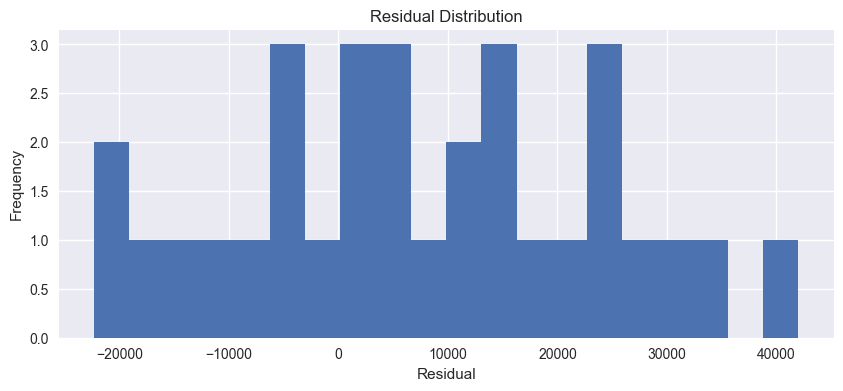

In [7]:
best_model = metrics_df.iloc[0]["model"]
best_preds = predictions[best_model]

eval_df = test_df[["date", "trips", "trips_capped", "post_congestion_pricing"]].copy()
eval_df["predicted_trips"] = best_preds
eval_df["residual"] = eval_df["trips_capped"] - eval_df["predicted_trips"]

fig = px.line(
    eval_df,
    x="date",
    y=["trips_capped", "predicted_trips"],
    title=f"Actual vs Predicted ({best_model})",
)
fig.show()

plt.figure(figsize=(10, 4))
plt.hist(eval_df["residual"], bins=20)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [8]:
policy_summary = (
    df.groupby("post_congestion_pricing", as_index=False)["trips"]
    .mean()
    .rename(columns={"trips": "avg_trips"})
)
policy_summary["period"] = policy_summary["post_congestion_pricing"].map({0: "Pre", 1: "Post"})
display(policy_summary[["period", "avg_trips"]])

fig_policy = px.bar(policy_summary, x="period", y="avg_trips", title="Average Trips: Pre vs Post Congestion Pricing")
fig_policy.show()

# Save evaluation artifacts for dashboard/reporting
output_dir = Path("../outputs")
figures_dir = output_dir / "figures"
models_dir = output_dir / "models"
figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(models_dir / "model_metrics.csv", index=False)
eval_df.to_csv(models_dir / "test_predictions.csv", index=False)
df.to_csv(Path("../data/processed/nyc_taxi_demand_congestion_combined_daily.csv"), index=False)
print("Saved model_metrics.csv, test_predictions.csv, and processed CSV.")

,period,avg_trips
0,Pre,118135.230769
1,Post,125975.953488


Saved model_metrics.csv, test_predictions.csv, and processed CSV.


## Starter Code (Trip-Level Baseline)
Clean starter script for a single recent monthly TLC parquet file.

Expected file path: `data/raw/yellow_tripdata_2025-01.parquet`

Shape: (3475226, 20)
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2025-01-01 00:18:38   2025-01-01 00:26:59              1.0   
1         1  2025-01-01 00:32:40   2025-01-01 00:35:13              1.0   
2         1  2025-01-01 00:44:04   2025-01-01 00:46:01              1.0   
3         2  2025-01-01 00:14:27   2025-01-01 00:20:01              3.0   
4         2  2025-01-01 00:21:34   2025-01-01 00:25:06              3.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.60         1.0                  N           229           237   
1           0.50         1.0                  N           236           237   
2           0.60         1.0                  N           141           141   
3           0.52         1.0                  N           244           244   
4           0.66         1.0                  N           244           116   

   payment_type  fare_amount  extra  mta_tax  tip_amo

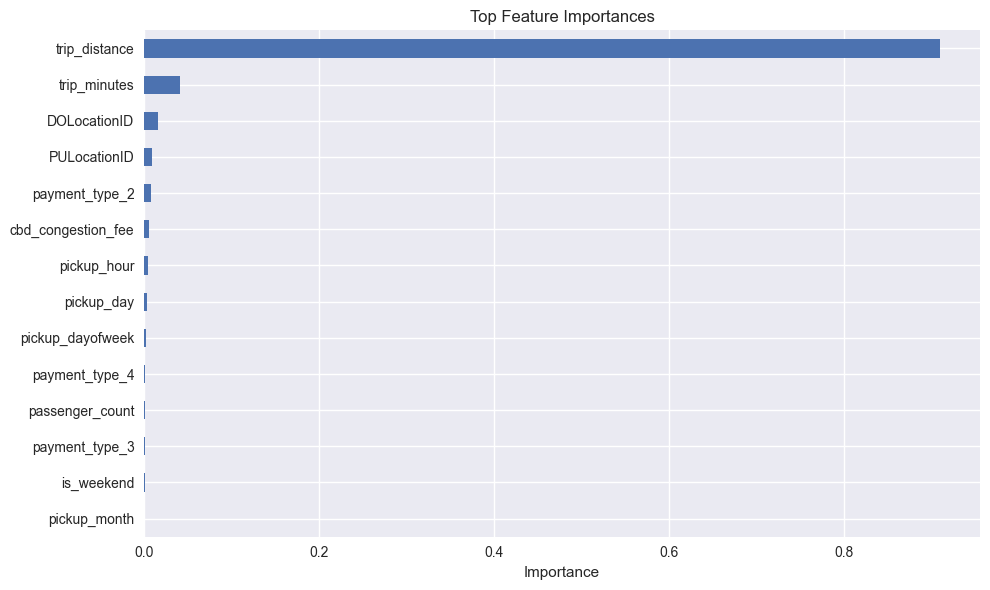

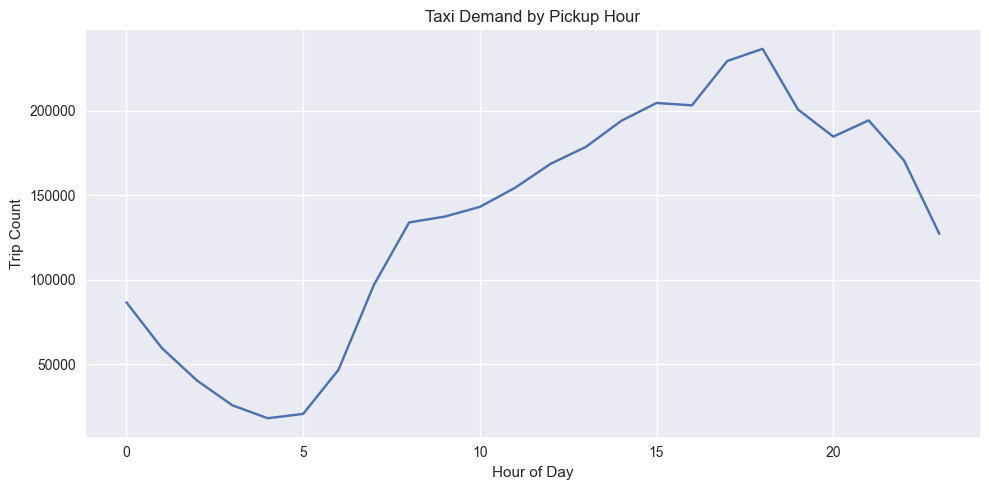


Average CBD congestion fee by pickup hour:
pickup_hour
0     0.536956
1     0.539155
2     0.535429
3     0.514292
4     0.443526
5     0.409809
6     0.455942
7     0.451480
8     0.477831
9     0.475793
10    0.457204
11    0.459835
12    0.453851
13    0.463364
14    0.455204
15    0.449283
16    0.470791
17    0.497258
18    0.515935
19    0.520567
20    0.533176
21    0.545038
22    0.556900
23    0.553375
Name: cbd_congestion_fee, dtype: float64


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 1. Load data
# -----------------------------
DATA_PATH = Path("data/raw/yellow_tripdata_2025-01.parquet")

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

# -----------------------------
# 2. Basic cleaning
# -----------------------------
keep_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type",
    "cbd_congestion_fee"
]

existing_cols = [c for c in keep_cols if c in df.columns]
df = df[existing_cols].copy()

df = df.dropna(subset=["tpep_pickup_datetime", "trip_distance", "fare_amount", "total_amount"])
df = df[df["trip_distance"] > 0]
df = df[df["fare_amount"] > 0]
df = df[df["total_amount"] > 0]

# Remove extreme outliers for a portfolio-friendly baseline
df = df[df["trip_distance"] < 100]
df = df[df["fare_amount"] < 500]
df = df[df["total_amount"] < 500]

# -----------------------------
# 3. Feature engineering
# -----------------------------
df["pickup_dt"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["dropoff_dt"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

df["pickup_hour"] = df["pickup_dt"].dt.hour
df["pickup_dayofweek"] = df["pickup_dt"].dt.dayofweek
df["pickup_day"] = df["pickup_dt"].dt.day
df["pickup_month"] = df["pickup_dt"].dt.month
df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

if "dropoff_dt" in df.columns:
    trip_minutes = (df["dropoff_dt"] - df["pickup_dt"]).dt.total_seconds() / 60
    df["trip_minutes"] = trip_minutes.clip(lower=1, upper=300)
else:
    df["trip_minutes"] = np.nan

# Target: total_amount
target = "total_amount"

feature_cols = [
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_month",
    "is_weekend",
]

optional_cols = ["passenger_count", "payment_type", "PULocationID", "DOLocationID", "trip_minutes", "cbd_congestion_fee"]
feature_cols += [c for c in optional_cols if c in df.columns]

model_df = df[feature_cols + [target]].dropna().copy()

# One-hot encode low-cardinality fields only
categorical_cols = [c for c in ["payment_type"] if c in model_df.columns]
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

X = model_df.drop(columns=[target])
y = model_df[target]

# Sample for faster local runs
if len(model_df) > 100_000:
    sample_idx = np.random.RandomState(42).choice(model_df.index, size=100_000, replace=False)
    X = X.loc[sample_idx]
    y = y.loc[sample_idx]

# -----------------------------
# 4. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Baseline model
# -----------------------------
model = RandomForestRegressor(
    n_estimators=120,
    max_depth=14,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.3f}")
print(f"R^2: {r2:.3f}")

# -----------------------------
# 6. Feature importance
# -----------------------------
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Demand by hour
# -----------------------------
hourly_demand = df.groupby("pickup_hour").size()

plt.figure(figsize=(10, 5))
hourly_demand.plot()
plt.title("Taxi Demand by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Congestion fee quick check
# -----------------------------
if "cbd_congestion_fee" in df.columns:
    fee_summary = df.groupby("pickup_hour")["cbd_congestion_fee"].mean()
    print("\nAverage CBD congestion fee by pickup hour:")
    print(fee_summary)

## Version 1 Status (Baseline Complete)
- ✅ Predict `total_amount`
- ✅ Show feature importance
- ✅ Show peak demand by hour/day
- ✅ Provide business takeaways in README

Top 5 peak pickup hours (by trip count):


,trip_count
pickup_hour,
18,236572
17,229363
15,204511
16,203122
19,200647


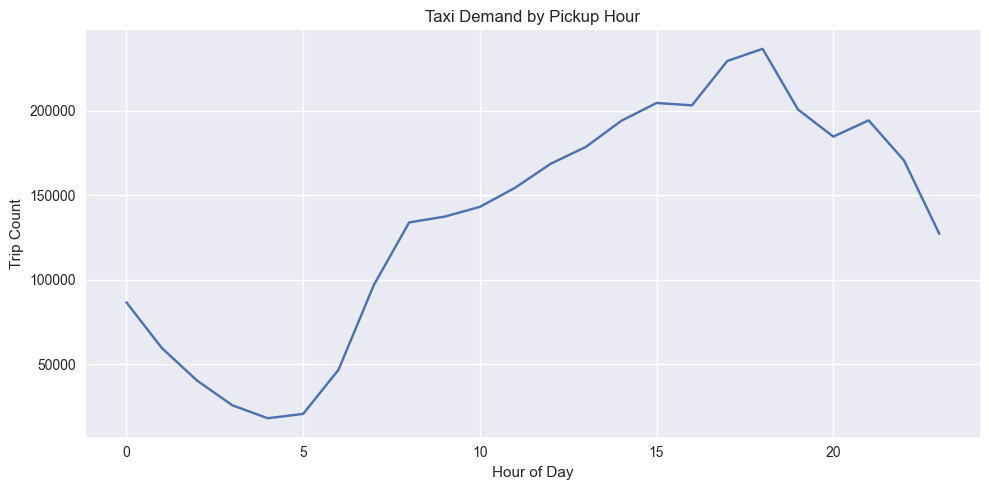

Top 3 peak days (by trip count):


,trip_count
pickup_dayofweek,
Thursday,571819
Friday,544288
Wednesday,537189


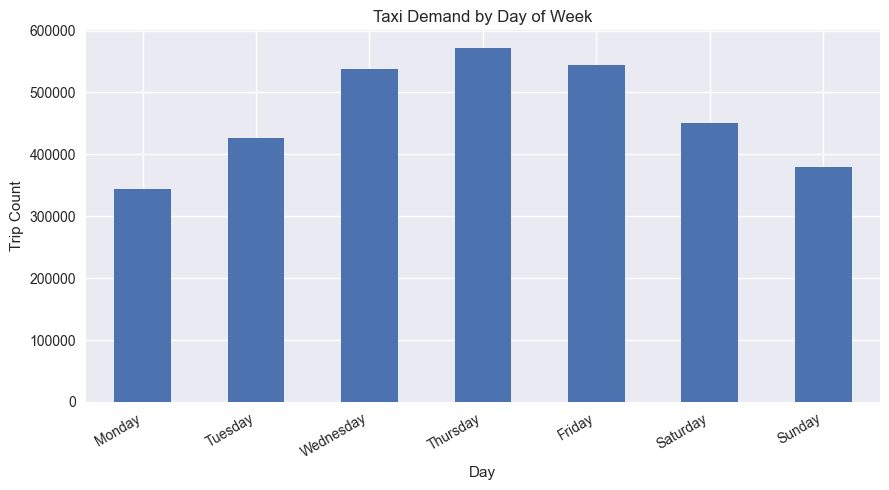

In [12]:
if "df" not in globals():
    raise RuntimeError("Run the starter code cell first so `df` is available.")

# Peak demand by pickup hour
hourly_demand = df.groupby("pickup_hour").size().sort_values(ascending=False)
peak_hours = hourly_demand.head(5)

print("Top 5 peak pickup hours (by trip count):")
display(peak_hours.rename("trip_count").to_frame())

plt.figure(figsize=(10, 5))
hourly_demand.sort_index().plot()
plt.title("Taxi Demand by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

# Peak demand by day of week
day_name_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

if "pickup_dayofweek" in df.columns:
    dow = df["pickup_dayofweek"]
else:
    dow = pd.to_datetime(df["tpep_pickup_datetime"]).dt.dayofweek

day_demand = dow.value_counts().sort_index()
day_demand.index = day_demand.index.map(day_name_map)
peak_days = day_demand.sort_values(ascending=False).head(3)

print("Top 3 peak days (by trip count):")
display(peak_days.rename("trip_count").to_frame())

plt.figure(figsize=(9, 5))
day_demand.plot(kind="bar")
plt.title("Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Trip Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Time-Based Validation (Out-of-Time)
This section validates the trip-level model with a chronological split and compares it to a random split baseline.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

tb_df = df.copy()

# Ensure time and engineered columns exist
tb_df["pickup_dt"] = pd.to_datetime(tb_df["tpep_pickup_datetime"], errors="coerce")
if "pickup_dayofweek" not in tb_df.columns:
    tb_df["pickup_dayofweek"] = tb_df["pickup_dt"].dt.dayofweek
if "pickup_hour" not in tb_df.columns:
    tb_df["pickup_hour"] = tb_df["pickup_dt"].dt.hour
if "pickup_day" not in tb_df.columns:
    tb_df["pickup_day"] = tb_df["pickup_dt"].dt.day
if "pickup_month" not in tb_df.columns:
    tb_df["pickup_month"] = tb_df["pickup_dt"].dt.month
if "is_weekend" not in tb_df.columns:
    tb_df["is_weekend"] = tb_df["pickup_dayofweek"].isin([5, 6]).astype(int)
if "trip_minutes" not in tb_df.columns and "tpep_dropoff_datetime" in tb_df.columns:
    dropoff_dt = pd.to_datetime(tb_df["tpep_dropoff_datetime"], errors="coerce")
    trip_minutes = (dropoff_dt - tb_df["pickup_dt"]).dt.total_seconds() / 60
    tb_df["trip_minutes"] = trip_minutes.clip(lower=1, upper=300)

tb_feature_cols = [
    "trip_distance", "pickup_hour", "pickup_dayofweek", "pickup_day", "pickup_month", "is_weekend",
    "passenger_count", "PULocationID", "DOLocationID", "trip_minutes", "cbd_congestion_fee", "payment_type",
]
tb_feature_cols = [c for c in tb_feature_cols if c in tb_df.columns]

tb_model_df = tb_df[tb_feature_cols + ["total_amount", "pickup_dt"]].dropna().copy()
tb_model_df = pd.get_dummies(tb_model_df, columns=[c for c in ["payment_type"] if c in tb_model_df.columns], drop_first=True)
tb_model_df = tb_model_df.sort_values("pickup_dt").reset_index(drop=True)

X_tb = tb_model_df.drop(columns=["total_amount", "pickup_dt"])
y_tb = tb_model_df["total_amount"]

# Chronological 80/20 split
split_idx = int(len(tb_model_df) * 0.8)
X_train_time, X_test_time = X_tb.iloc[:split_idx], X_tb.iloc[split_idx:]
y_train_time, y_test_time = y_tb.iloc[:split_idx], y_tb.iloc[split_idx:]

time_model = RandomForestRegressor(
    n_estimators=120, max_depth=14, min_samples_leaf=5, random_state=42, n_jobs=-1
)
time_model.fit(X_train_time, y_train_time)
time_preds = time_model.predict(X_test_time)

mae_time = mean_absolute_error(y_test_time, time_preds)
r2_time = r2_score(y_test_time, time_preds)

# Random split benchmark for comparison
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_tb, y_tb, test_size=0.2, random_state=42
)
rand_model = RandomForestRegressor(
    n_estimators=120, max_depth=14, min_samples_leaf=5, random_state=42, n_jobs=-1
)
rand_model.fit(X_train_rand, y_train_rand)
rand_preds = rand_model.predict(X_test_rand)

mae_rand = mean_absolute_error(y_test_rand, rand_preds)
r2_rand = r2_score(y_test_rand, rand_preds)

time_validation_results = pd.DataFrame([
    {"split": "Time-based (chronological)", "mae": mae_time, "r2": r2_time, "rows_test": len(y_test_time)},
    {"split": "Random split", "mae": mae_rand, "r2": r2_rand, "rows_test": len(y_test_rand)},
])

print("Time-based validation vs random split:")
display(time_validation_results)

print(f"Time-based MAE: {mae_time:.3f} | R^2: {r2_time:.3f}")
print(f"Random-split MAE: {mae_rand:.3f} | R^2: {r2_rand:.3f}")

Time-based validation vs random split:


,split,mae,r2,rows_test
0,Time-based (chronological),1.824634,0.954493,568078
1,Random split,1.874755,0.949811,568078


Time-based MAE: 1.825 | R^2: 0.954
Random-split MAE: 1.875 | R^2: 0.950


## Rolling-Origin Backtesting
Expanding-window backtesting on chronologically ordered trip-level data.

Notes:
- Uses multiple out-of-time folds
- Uses a capped sample size for practical local runtime
- Reports fold-level and aggregate metrics

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

if "tb_model_df" not in globals():
    raise RuntimeError("Run the Time-Based Validation cell first (it creates tb_model_df).")

roll_df = tb_model_df.copy().sort_values("pickup_dt").reset_index(drop=True)

# Keep runtime practical on local machine
MAX_ROWS = 500_000
if len(roll_df) > MAX_ROWS:
    sampled = np.random.RandomState(42).choice(roll_df.index, size=MAX_ROWS, replace=False)
    roll_df = roll_df.loc[sampled].sort_values("pickup_dt").reset_index(drop=True)

X_roll = roll_df.drop(columns=["total_amount", "pickup_dt"])
y_roll = roll_df["total_amount"]
t_roll = roll_df["pickup_dt"]

n_splits = 4
test_size = max(20_000, int(len(roll_df) * 0.1))
initial_train_end = max(int(len(roll_df) * 0.5), 50_000)

fold_rows = []
for fold in range(1, n_splits + 1):
    train_end = initial_train_end + (fold - 1) * test_size
    test_end = min(train_end + test_size, len(roll_df))

    if test_end - train_end < 5_000 or train_end <= 10_000:
        break

    X_train_f = X_roll.iloc[:train_end]
    y_train_f = y_roll.iloc[:train_end]
    X_test_f = X_roll.iloc[train_end:test_end]
    y_test_f = y_roll.iloc[train_end:test_end]

    fold_model = RandomForestRegressor(
        n_estimators=60,
        max_depth=14,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
    fold_model.fit(X_train_f, y_train_f)
    preds_f = fold_model.predict(X_test_f)

    fold_rows.append({
        "fold": fold,
        "train_rows": len(X_train_f),
        "test_rows": len(X_test_f),
        "test_start": t_roll.iloc[train_end],
        "test_end": t_roll.iloc[test_end - 1],
        "mae": mean_absolute_error(y_test_f, preds_f),
        "r2": r2_score(y_test_f, preds_f),
    })

rolling_results = pd.DataFrame(fold_rows)
display(rolling_results)

rolling_summary = pd.DataFrame([
    {
        "metric": "mae_mean",
        "value": rolling_results["mae"].mean(),
    },
    {
        "metric": "mae_std",
        "value": rolling_results["mae"].std(ddof=0),
    },
    {
        "metric": "r2_mean",
        "value": rolling_results["r2"].mean(),
    },
    {
        "metric": "r2_std",
        "value": rolling_results["r2"].std(ddof=0),
    },
])
display(rolling_summary)

print(
    f"Rolling-origin MAE mean: {rolling_results['mae'].mean():.3f} | "
    f"R^2 mean: {rolling_results['r2'].mean():.3f}"
)

,fold,train_rows,test_rows,test_start,test_end,mae,r2
0,1,250000,50000,2025-01-16 21:30:47,2025-01-20 03:18:59,1.951573,0.940515
1,2,300000,50000,2025-01-20 03:21:23,2025-01-23 12:15:17,2.021975,0.939320
2,3,350000,50000,2025-01-23 12:15:18,2025-01-25 23:12:42,1.810933,0.945865
3,4,400000,50000,2025-01-25 23:12:42,2025-01-29 11:21:33,1.908203,0.954629


,metric,value
0,mae_mean,1.923171
1,mae_std,0.076469
2,r2_mean,0.945082
3,r2_std,0.006038


Rolling-origin MAE mean: 1.923 | R^2 mean: 0.945


## Three-Version Upgrade Comparison
| Version | Scope | Status | Comparison Summary |
|---|---|---|---|
| Version 1 (Baseline) | Trip-level fare prediction + feature importance + demand patterns | ✅ Done | Strong baseline signal (RandomForest MAE 2.012, R² 0.944 on random split). |
| Version 2 (Differentiated) | Zone-level hourly demand + weather integration + dashboard | 🟡 Next | Increases business relevance and stakeholder usability vs V1. |
| Version 3 (Advanced) | Temporal validation + boosted models + SHAP + deployed app | 🟡 In progress | More production-like reliability and explainability than V1/V2. |

## Boosted Model Comparison (XGBoost / LightGBM / RandomForest)
Chronological out-of-time comparison on trip-level fare prediction using a practical sample size for local runtime.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

boost_data_path = Path("data/raw/yellow_tripdata_2025-01.parquet")
if not boost_data_path.exists():
    raise FileNotFoundError(f"Missing parquet at {boost_data_path.resolve()}")

boost_df = pd.read_parquet(boost_data_path)

keep_cols = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
    "passenger_count", "trip_distance", "fare_amount", "total_amount",
    "payment_type", "cbd_congestion_fee",
]
keep_cols = [c for c in keep_cols if c in boost_df.columns]
boost_df = boost_df[keep_cols].copy()

boost_df = boost_df.dropna(subset=["tpep_pickup_datetime", "trip_distance", "fare_amount", "total_amount"])
boost_df = boost_df[(boost_df["trip_distance"] > 0) & (boost_df["fare_amount"] > 0) & (boost_df["total_amount"] > 0)]
boost_df = boost_df[(boost_df["trip_distance"] < 100) & (boost_df["fare_amount"] < 500) & (boost_df["total_amount"] < 500)]

boost_df["pickup_dt"] = pd.to_datetime(boost_df["tpep_pickup_datetime"], errors="coerce")
boost_df["dropoff_dt"] = pd.to_datetime(boost_df.get("tpep_dropoff_datetime"), errors="coerce")
boost_df["pickup_hour"] = boost_df["pickup_dt"].dt.hour
boost_df["pickup_dayofweek"] = boost_df["pickup_dt"].dt.dayofweek
boost_df["pickup_day"] = boost_df["pickup_dt"].dt.day
boost_df["pickup_month"] = boost_df["pickup_dt"].dt.month
boost_df["is_weekend"] = boost_df["pickup_dayofweek"].isin([5, 6]).astype(int)
trip_minutes = (boost_df["dropoff_dt"] - boost_df["pickup_dt"]).dt.total_seconds() / 60
boost_df["trip_minutes"] = trip_minutes.clip(lower=1, upper=300)

base_features = [
    "trip_distance", "pickup_hour", "pickup_dayofweek", "pickup_day", "pickup_month", "is_weekend",
    "passenger_count", "PULocationID", "DOLocationID", "trip_minutes", "cbd_congestion_fee", "payment_type",
]
base_features = [c for c in base_features if c in boost_df.columns]

boost_model_df = boost_df[base_features + ["total_amount", "pickup_dt"]].dropna().copy()
boost_model_df = pd.get_dummies(
    boost_model_df,
    columns=[c for c in ["payment_type"] if c in boost_model_df.columns],
    drop_first=True,
    dtype=float,
 )
boost_model_df = boost_model_df.sort_values("pickup_dt").reset_index(drop=True)

MAX_BOOST_ROWS = 350_000
if len(boost_model_df) > MAX_BOOST_ROWS:
    sample_idx = np.random.RandomState(42).choice(boost_model_df.index, size=MAX_BOOST_ROWS, replace=False)
    boost_model_df = boost_model_df.loc[sample_idx].sort_values("pickup_dt").reset_index(drop=True)

X_boost = boost_model_df.drop(columns=["total_amount", "pickup_dt"]).astype(float)
y_boost = boost_model_df["total_amount"].astype(float)

split_idx = int(len(boost_model_df) * 0.8)
X_train_b, X_test_b = X_boost.iloc[:split_idx], X_boost.iloc[split_idx:]
y_train_b, y_test_b = y_boost.iloc[:split_idx], y_boost.iloc[split_idx:]

candidate_models = []
candidate_models.append(("RandomForest", RandomForestRegressor(
    n_estimators=120, max_depth=14, min_samples_leaf=5, random_state=42, n_jobs=-1
)))

try:
    from xgboost import XGBRegressor
    candidate_models.append(("XGBoost", XGBRegressor(
        n_estimators=250,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1,
    )))
except Exception as exc:
    print(f"XGBoost unavailable: {exc}")

try:
    from lightgbm import LGBMRegressor
    candidate_models.append(("LightGBM", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
    )))
except Exception as exc:
    print(f"LightGBM unavailable: {exc}")

boost_rows = []
for name, mdl in candidate_models:
    mdl.fit(X_train_b, y_train_b)
    preds = mdl.predict(X_test_b)
    boost_rows.append({
        "model": name,
        "mae": mean_absolute_error(y_test_b, preds),
        "r2": r2_score(y_test_b, preds),
        "rows_train": len(X_train_b),
        "rows_test": len(X_test_b),
    })

boosted_comparison_results = pd.DataFrame(boost_rows).sort_values("mae")
display(boosted_comparison_results)

best_boosted_model = boosted_comparison_results.iloc[0]["model"] if len(boosted_comparison_results) else "N/A"
print(f"Best model by MAE: {best_boosted_model}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1041
[LightGBM] [Info] Number of data points in the train set: 280000, number of used features: 13
[LightGBM] [Info] Start training from score 27.329414


,model,mae,r2,rows_train,rows_test
1,XGBoost,1.884276,0.943636,280000,70000
2,LightGBM,1.900321,0.948911,280000,70000
0,RandomForest,1.929356,0.947613,280000,70000


Best model by MAE: XGBoost


## SHAP Explainability (Global + Local)
Explains the best boosted model with SHAP values to show feature impact globally and for an individual prediction.

c:\Users\Owner\ai-document-analyzer\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,mean_abs_shap
trip_distance,10.543354
trip_minutes,3.367101
payment_type_2,1.009321
cbd_congestion_fee,0.808581
pickup_hour,0.796181
DOLocationID,0.694140
PULocationID,0.674897
pickup_dayofweek,0.288303
passenger_count,0.159973
pickup_day,0.135304


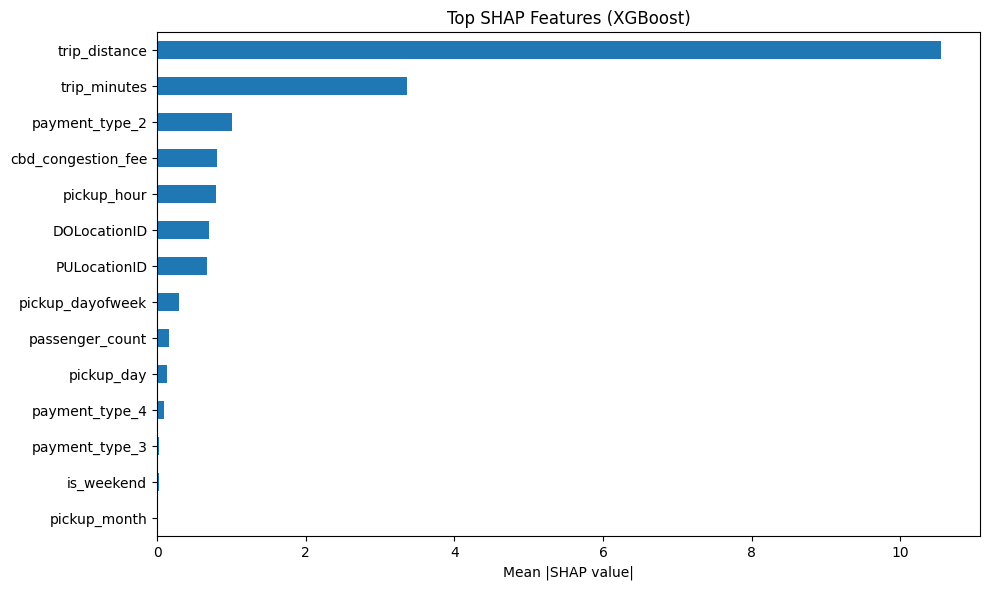

,shap_value
trip_distance,-10.342931
trip_minutes,-2.507309
pickup_hour,-0.963223
cbd_congestion_fee,0.548408
payment_type_2,0.520777
PULocationID,-0.230883
pickup_dayofweek,0.157581
pickup_day,0.105001
DOLocationID,-0.102862
passenger_count,-0.078291


SHAP model used: XGBoost
Base value: 27.335
Predicted value (sample row): 14.522
Base + SHAP sum: 14.522


In [2]:
import shap
import matplotlib.pyplot as plt

if "X_train_b" not in globals() or "X_test_b" not in globals() or "y_train_b" not in globals():
    raise RuntimeError("Run the boosted model comparison cell first.")

# Rebuild a compact best-model candidate for explanation
try:
    from xgboost import XGBRegressor
    shap_model_name = "XGBoost"
    shap_model = XGBRegressor(
        n_estimators=250,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1,
    )
except Exception:
    try:
        from lightgbm import LGBMRegressor
        shap_model_name = "LightGBM"
        shap_model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
        )
    except Exception:
        from sklearn.ensemble import RandomForestRegressor
        shap_model_name = "RandomForest"
        shap_model = RandomForestRegressor(
            n_estimators=120,
            max_depth=14,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )

shap_model.fit(X_train_b, y_train_b)

sample_n = min(2000, len(X_test_b))
X_shap = X_test_b.sample(sample_n, random_state=42).copy()

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_array = shap_values[0]
else:
    shap_array = shap_values

shap_importance = pd.Series(np.abs(shap_array).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
display(shap_importance.head(15).rename("mean_abs_shap").to_frame())

plt.figure(figsize=(10, 6))
shap_importance.head(15).sort_values().plot(kind="barh")
plt.title(f"Top SHAP Features ({shap_model_name})")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# Local explanation for one example
local_idx = 0
x_local = X_shap.iloc[[local_idx]]
pred_local = float(shap_model.predict(x_local)[0])

if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = float(np.array(explainer.expected_value).ravel()[0])
else:
    base_value = float(explainer.expected_value)

local_shap = pd.Series(shap_array[local_idx], index=X_shap.columns)
top_local = local_shap.reindex(local_shap.abs().sort_values(ascending=False).index).head(10)
display(top_local.rename("shap_value").to_frame())

print(f"SHAP model used: {shap_model_name}")
print(f"Base value: {base_value:.3f}")
print(f"Predicted value (sample row): {pred_local:.3f}")
print(f"Base + SHAP sum: {(base_value + local_shap.sum()):.3f}")

## Summary and Recommendations
### Key Findings
- Demand peaks in late afternoon/evening, with strongest weekday concentration around Thursday and Friday.
- Fare prediction performance is strong across baseline and boosted models, with XGBoost best by MAE in current runs.
- Temporal validation confirms robust out-of-time performance and reduces overconfidence from random splits.
- SHAP interpretation shows trip distance and trip duration proxy (`trip_minutes`) as dominant drivers of fare predictions.

### Recommendations
1. **Operational planning:** align driver/supply allocation toward peak hours (especially 15:00–19:00).
2. **Modeling roadmap:** continue with zone-level hourly forecasting to improve tactical dispatch decisions.
3. **Policy analytics:** expand pre/post analysis with stronger causal controls (seasonality/events) before policy claims.
4. **Deployment:** publish Streamlit app outputs for non-technical stakeholders and include confidence/uncertainty indicators.
5. **Next technical upgrade:** add multi-month rolling-origin retraining and monitoring for model drift.